In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [25]:
# Carregando as vendas
vendas = pd.read_csv('vendas_urban_style.csv', sep=';')
vendas.head() # Visualiza os primeiros 5 dados

,id_venda,data_venda,cliente_id,produto_id,vendedor_responsavel_id,canal_venda,quantidade,preco_unitario,valor_bruto,desconto_percentual,...,custo_total,lucro_bruto,margem_percentual,forma_pagamento,parcelas,status,cidade_entrega,estado_entrega,centro_custo,observacoes
0,VEN0001,2025-08-01,CLI114,PROD019,FUN024,E-commerce,2,257.17,514.34,0.0,...,302.0,212.34,41.3,Boleto,1,Concluída,Osasco,SP,CC-COMERCIAL,Venda regular.
1,VEN0002,2025-08-01,CLI118,PROD077,FUN024,Loja Física,3,177.76,533.28,0.0,...,195.0,338.28,63.4,PIX,6,Concluída,Guarulhos,SP,CC-COMERCIAL,Venda regular.
2,VEN0003,2025-08-05,CLI043,PROD011,FUN036,WhatsApp,1,283.61,283.61,0.0,...,127.0,156.61,55.2,PIX,6,Concluída,Guarulhos,SP,CC-COMERCIAL,Venda regular.
3,VEN0004,2025-08-05,CLI042,PROD011,FUN036,E-commerce,1,283.61,283.61,0.0,...,127.0,156.61,55.2,PIX,1,Concluída,São Bernardo,SP,CC-COMERCIAL,Venda regular.
4,VEN0005,2025-08-05,CLI081,PROD072,FUN025,Loja Física,3,145.08,435.24,0.0,...,156.0,279.24,64.2,Boleto,6,Devolvida,São Bernardo,SP,CC-COMERCIAL,Venda regular.


In [26]:
vendas.info() # Conhecer os dados, qtd de linhas, colunas e tipos

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_venda                 900 non-null    str    
 1   data_venda               900 non-null    str    
 2   cliente_id               900 non-null    str    
 3   produto_id               900 non-null    str    
 4   vendedor_responsavel_id  900 non-null    str    
 5   canal_venda              900 non-null    str    
 6   quantidade               900 non-null    int64  
 7   preco_unitario           900 non-null    float64
 8   valor_bruto              900 non-null    float64
 9   desconto_percentual      900 non-null    float64
 10  valor_desconto           900 non-null    float64
 11  valor_liquido            900 non-null    float64
 12  custo_total              900 non-null    float64
 13  lucro_bruto              900 non-null    float64
 14  margem_percentual        900 non-null

In [27]:
vendas.isnull().sum() # Verifica se tem algum dado faltante

id_venda                   0
data_venda                 0
cliente_id                 0
produto_id                 0
vendedor_responsavel_id    0
canal_venda                0
quantidade                 0
preco_unitario             0
valor_bruto                0
desconto_percentual        0
valor_desconto             0
valor_liquido              0
custo_total                0
lucro_bruto                0
margem_percentual          0
forma_pagamento            0
parcelas                   0
status                     0
cidade_entrega             0
estado_entrega             0
centro_custo               0
observacoes                0
dtype: int64

In [28]:
vendas.describe() # Mostra as estatisticas

,quantidade,preco_unitario,valor_bruto,desconto_percentual,valor_desconto,valor_liquido,custo_total,lucro_bruto,margem_percentual,parcelas
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1.565556,230.530567,354.441700,3.450000,12.533522,281.646767,159.977778,149.395656,42.720333,2.460000
std,0.749588,110.256200,239.705323,5.237703,25.862189,247.670683,106.795583,138.810850,21.572771,1.704395
min,1.000000,57.260000,57.260000,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,1.000000
25%,1.000000,144.710000,176.887500,0.000000,0.000000,118.187500,80.000000,58.087500,41.300000,1.000000
50%,1.000000,216.480000,296.365000,0.000000,0.000000,239.640000,136.000000,117.960000,51.100000,2.000000
75%,2.000000,304.130000,450.200000,5.000000,16.020000,384.610000,184.500000,205.620000,57.700000,4.000000
max,4.000000,481.910000,1538.440000,20.000000,307.690000,1327.700000,672.000000,808.700000,64.200000,6.000000


In [29]:
vendas['data_venda'] = pd.to_datetime(vendas['data_venda']) # Convertendo a coluna data_venda para o tipo datetime (antes era string)
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_venda                 900 non-null    str           
 1   data_venda               900 non-null    datetime64[us]
 2   cliente_id               900 non-null    str           
 3   produto_id               900 non-null    str           
 4   vendedor_responsavel_id  900 non-null    str           
 5   canal_venda              900 non-null    str           
 6   quantidade               900 non-null    int64         
 7   preco_unitario           900 non-null    float64       
 8   valor_bruto              900 non-null    float64       
 9   desconto_percentual      900 non-null    float64       
 10  valor_desconto           900 non-null    float64       
 11  valor_liquido            900 non-null    float64       
 12  custo_total              900 non-null    float6

In [30]:
vendas_concluidas = vendas[vendas['status'] == 'Concluída'].copy() # Selecionando apenas as vendas que foram concluídas
vendas_concluidas.info() # Verifica a quantidade de dados que restaram

<class 'pandas.DataFrame'>
Index: 587 entries, 0 to 899
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_venda                 587 non-null    str           
 1   data_venda               587 non-null    datetime64[us]
 2   cliente_id               587 non-null    str           
 3   produto_id               587 non-null    str           
 4   vendedor_responsavel_id  587 non-null    str           
 5   canal_venda              587 non-null    str           
 6   quantidade               587 non-null    int64         
 7   preco_unitario           587 non-null    float64       
 8   valor_bruto              587 non-null    float64       
 9   desconto_percentual      587 non-null    float64       
 10  valor_desconto           587 non-null    float64       
 11  valor_liquido            587 non-null    float64       
 12  custo_total              587 non-null    float64    

In [31]:
vendas_concluidas['periodo'] = (vendas_concluidas['data_venda'].dt.to_period('M')) # Criando uma nova coluna chamada periodo, que vai pegar o ano e o mês da data da venda
vendas_concluidas[['data_venda','periodo']].head() # Visualizando as duas colunas, data_venda e periodo, para ver se a coluna periodo foi criada corretamente

,data_venda,periodo
0,2025-08-01,2025-08
1,2025-08-01,2025-08
2,2025-08-05,2025-08
3,2025-08-05,2025-08
5,2025-08-06,2025-08


In [32]:
# Resumindo algumas informações úteis daquele produto naquele mês, como quantidade vendida, preço médio, desconto médio, faturamento e lucro
vendas_mensais = (
    vendas_concluidas
    .groupby(
        ["produto_id", "periodo"]
    )
    .agg(
        quantidade_vendida=("quantidade", "sum"),
        preco_medio=("preco_unitario", "mean"),
        desconto_medio=("desconto_percentual", "mean"),
        faturamento=("valor_liquido", "sum"),
        lucro=("lucro_bruto", "sum")
    )
    .reset_index()
)
vendas_mensais.head() 

,produto_id,periodo,quantidade_vendida,preco_medio,desconto_medio,faturamento,lucro
0,PROD001,2025-09,3,144.71,0.0,434.13,233.13
1,PROD001,2025-12,1,144.71,5.0,137.47,70.47
2,PROD001,2026-01,1,144.71,0.0,144.71,77.71
3,PROD001,2026-02,2,144.71,0.0,289.42,155.42
4,PROD001,2026-03,7,144.71,0.0,1012.97,543.97


In [33]:
# Criando uma combinação de "TODOS OS PRODUTOS X TODOS OS 12 MESES"
produtos = vendas['produto_id'].unique()

# Criando uma lista de períodos mensais entre agosto de 2025 e julho de 2026
periodos = pd.period_range(
    start="2025-08",
    end="2026-07",
    freq="M"
)

In [34]:
# Criando um DataFrame com todas as combinações possíveis de produtos e períodos
grade_completa = pd.MultiIndex.from_product(
    [produtos, periodos],
    names=["produto_id", "periodo"]
).to_frame(index=False)

In [35]:
# Mesclando a grade completa com as vendas mensais
vendas_mensais = grade_completa.merge(vendas_mensais, on=['produto_id', 'periodo'], how='left').fillna(0) # Preenchendo os valores faltantes com 0
vendas_mensais.shape # Verificando a quantidade de linhas e colunas do DataFrame vendas_mensais

(960, 7)

In [36]:
# Ordenando o DataFrame vendas_mensais por produto_id e periodo
vendas_mensais = vendas_mensais.sort_values(
    ["produto_id", "periodo"]
).reset_index(drop=True)

In [37]:
# Criando colunas para mês e ano
vendas_mensais["mes"] = (
    vendas_mensais["periodo"].dt.month
)
vendas_mensais["ano"] = (
    vendas_mensais["periodo"].dt.year
)

CRIANDO OS LAGS - Feature Enginnering: transformando os dados disponiveis em informações que ajudarão o modelo a aprender

In [39]:
# Criando uma coluna para a quantidade vendida no mês anterior
vendas_mensais["venda_mes_anterior"] = (
    vendas_mensais
    .groupby("produto_id")["quantidade_vendida"]
    .shift(1)
)

In [40]:
# Criando uma coluna para a quantidade vendida no 2 meses anteriores
vendas_mensais["venda_2_meses"] = (
    vendas_mensais
    .groupby("produto_id")["quantidade_vendida"]
    .shift(2)
)

In [41]:
# Criando uma coluna para a quantidade vendida no 3 meses anteriores
vendas_mensais["venda_3_meses"] = (
    vendas_mensais
    .groupby("produto_id")["quantidade_vendida"]
    .shift(3)
)

In [ ]:
# Visualizando as vendas do produto PROD001
vendas_mensais[
    vendas_mensais["produto_id"] == "PROD001"
][
    [
        "periodo",
        "quantidade_vendida",
        "venda_mes_anterior",
        "venda_2_meses",
        "venda_3_meses"
    ]
]

,periodo,quantidade_vendida,venda_mes_anterior,venda_2_meses,venda_3_meses
0,2025-08,0.0,NaN,NaN,NaN
1,2025-09,3.0,0.0,NaN,NaN
2,2025-10,0.0,3.0,0.0,NaN
3,2025-11,0.0,0.0,3.0,0.0
4,2025-12,1.0,0.0,0.0,3.0
5,2026-01,1.0,1.0,0.0,0.0
6,2026-02,2.0,1.0,1.0,0.0
7,2026-03,7.0,2.0,1.0,1.0
8,2026-04,1.0,7.0,2.0,1.0
9,2026-05,1.0,1.0,7.0,2.0


In [45]:
# Criando uma coluna para a média de vendas dos 3 meses anteriores
vendas_mensais["media_3_meses"] = (
    vendas_mensais
    .groupby("produto_id")["quantidade_vendida"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3)
        .mean()
    )
)

In [46]:
# Criando uma coluna para a tendência de vendas, que é a diferença entre a venda do mês anterior e a venda de 2 meses atrás
vendas_mensais["tendencia"] = (
    vendas_mensais["venda_mes_anterior"]
    - vendas_mensais["venda_2_meses"]
)

In [ ]:
# Criando um novo DataFrame apenas com as colunas que serão utilizadas para o modelo de machine learning
dados_ml = vendas_mensais.dropna(
    subset=[
        "venda_mes_anterior",
        "venda_2_meses",
        "venda_3_meses",
        "media_3_meses"
    ]).copy()
dados_ml.shape

(720, 14)

In [ ]:
# Definindo as features e o target para o modelo de machine learning
features = [
    "mes",
    "venda_mes_anterior",
    "venda_2_meses",
    "venda_3_meses",
    "media_3_meses",
    "tendencia"
]

target = "quantidade_vendida"

X = dados_ml[features]

y = dados_ml[target]

In [ ]:
# Criando o conjunto de treino e teste
treino = dados_ml[dados_ml["periodo"]<= pd.Period("2026-05", freq="M")].copy()

teste = dados_ml[dados_ml["periodo"] > pd.Period("2026-05", freq="M")].copy()

In [60]:
# Definindo os conjuntos de treino e teste
X_train = treino[features]
y_train = treino[target]

X_test = teste[features]
y_test = teste[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (560, 6)
X_test: (160, 6)
y_train: (560,)
y_test: (160,)


In [65]:
# Criando uma previsão baseline, que é a previsão mais simples possível, que é a venda do mês anterior
previsao_baseline = (X_test["venda_mes_anterior"]
)

from sklearn.metrics import mean_absolute_error

mae_baseline = mean_absolute_error(y_test, previsao_baseline)

print("MAE Baseline:",mae_baseline)

MAE Baseline: 1.26875


In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(
    n_estimators=200, # 200 arvores de decisão
    max_depth=8, # Limita o tamanho das árvores de decisão
    random_state=42 # Faz com que o experimento seja reproduzivel
)

TREINANDO O MODELO

In [ ]:
# Treinando o modelo de machine learning
modelo.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [69]:
# Fazendo previsões com o modelo treinado
previsoes = modelo.predict(X_test)

In [74]:
# Avaliando o modelo de machine learning
resultado = teste[
    [
        "produto_id",
        "periodo",
        "quantidade_vendida"
    ]
].copy()

resultado["previsao"] = previsoes

resultado.head(20)

,produto_id,periodo,quantidade_vendida,previsao
10,PROD001,2026-06,0.0,1.510820
11,PROD001,2026-07,0.0,1.893320
22,PROD002,2026-06,1.0,0.357609
23,PROD002,2026-07,0.0,1.220342
34,PROD003,2026-06,3.0,1.220342
35,PROD003,2026-07,1.0,1.956052
46,PROD004,2026-06,1.0,0.491114
47,PROD004,2026-07,2.0,1.220342
58,PROD005,2026-06,0.0,1.624846
59,PROD005,2026-07,1.0,0.693504


In [77]:
resultado["previsao_arredondada"] = (
    resultado["previsao"]
    .round()
    .astype(int)
)
resultado.head(20)

,produto_id,periodo,quantidade_vendida,previsao,previsao_arredondada
10,PROD001,2026-06,0.0,1.510820,2
11,PROD001,2026-07,0.0,1.893320,2
22,PROD002,2026-06,1.0,0.357609,0
23,PROD002,2026-07,0.0,1.220342,1
34,PROD003,2026-06,3.0,1.220342,1
35,PROD003,2026-07,1.0,1.956052,2
46,PROD004,2026-06,1.0,0.491114,0
47,PROD004,2026-07,2.0,1.220342,1
58,PROD005,2026-06,0.0,1.624846,2
59,PROD005,2026-07,1.0,0.693504,1


AVALIANDO O MACHINE LEARNING

In [ ]:
# Avaliando o modelo de machine learning
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# O modelo erra, em média, aproximadamente XXX unidades por previsão
mae = mean_absolute_error(
    y_test,
    previsoes
)

In [ ]:
# Também mede erro, mas penaliza erros grandes mais fortemente, se o modelo acertar quase tudo, mas errar um produto por 30 unidades, o RMSE sentirá bastante
rmse = mean_squared_error(
    y_test,
    previsoes
) ** 0.5

In [82]:
# O R2 mede o quanto o modelo explica a variância dos dados, quanto mais próximo de 1, melhor
r2 = r2_score(
    y_test,
    previsoes
)

In [100]:
# Comparando Baseline X Machine Learning
print("MAE Baseline:",round(mae_baseline, 2))

print("MAE Random Forest:",round(mae, 2))

print("RMSE Random Forest:",round(rmse, 2))

print("R2 Random Forest:",round(r2, 2))

MAE Baseline: 1.27
MAE Random Forest: 1.17
RMSE Random Forest: 1.53
R2 Random Forest: -0.18


In [86]:
# Calculando a melhoria do modelo de machine learning em relação ao baseline
melhoria = (
    (mae_baseline - mae)
    / mae_baseline
) * 100

print(
    f"Melhoria: {melhoria:.2f}%"
)

Melhoria: 7.95%


VISUALIZANDO REAL X PREVISTO

In [91]:
produto_exemplo = "PROD016"

grafico = resultado[
    resultado["produto_id"]
    == produto_exemplo
]

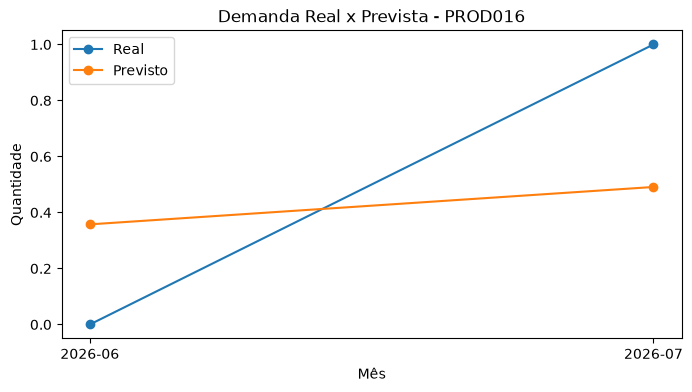

In [92]:
plt.figure(figsize=(8, 4))

plt.plot(
    grafico["periodo"].astype(str),
    grafico["quantidade_vendida"],
    marker="o",
    label="Real"
)

plt.plot(
    grafico["periodo"].astype(str),
    grafico["previsao"],
    marker="o",
    label="Previsto"
)

plt.xlabel("Mês")
plt.ylabel("Quantidade")

plt.title(
    f"Demanda Real x Prevista - {produto_exemplo}"
)

plt.legend()

plt.show()

In [93]:
importancias = pd.DataFrame({
    "variavel": features,
    "importancia": modelo.feature_importances_
})
importancias = importancias.sort_values(
    "importancia",
    ascending=False
)
importancias

,variavel,importancia
4,media_3_meses,0.230862
0,mes,0.228144
3,venda_3_meses,0.193781
5,tendencia,0.146976
1,venda_mes_anterior,0.105272
2,venda_2_meses,0.094965


In [99]:
import joblib

joblib.dump(
    modelo,
    "modelo_demanda_duaxis.pkl"
)

['modelo_demanda_duaxis.pkl']